In [18]:
import numpy as np
import pandas as pd
import random as random
import matplotlib.pyplot as plt
import math

In [20]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.optimize import minimize
from scipy.special import comb

In [6]:
#Modelos de la dependencia P(Y=1 | x)

#Logístico
alpha1 = -5
beta1 = 2
def logist(x,alpha = alpha1, beta=beta1):
    e = np.exp(alpha + beta*x)
    return e/(1+e)

#Log-log complementario
alpha2 = -2
beta2 = 2

def log_com(x, alpha = alpha2, beta = beta2):
    return 1 - np.exp(-np.exp(alpha + beta*x))

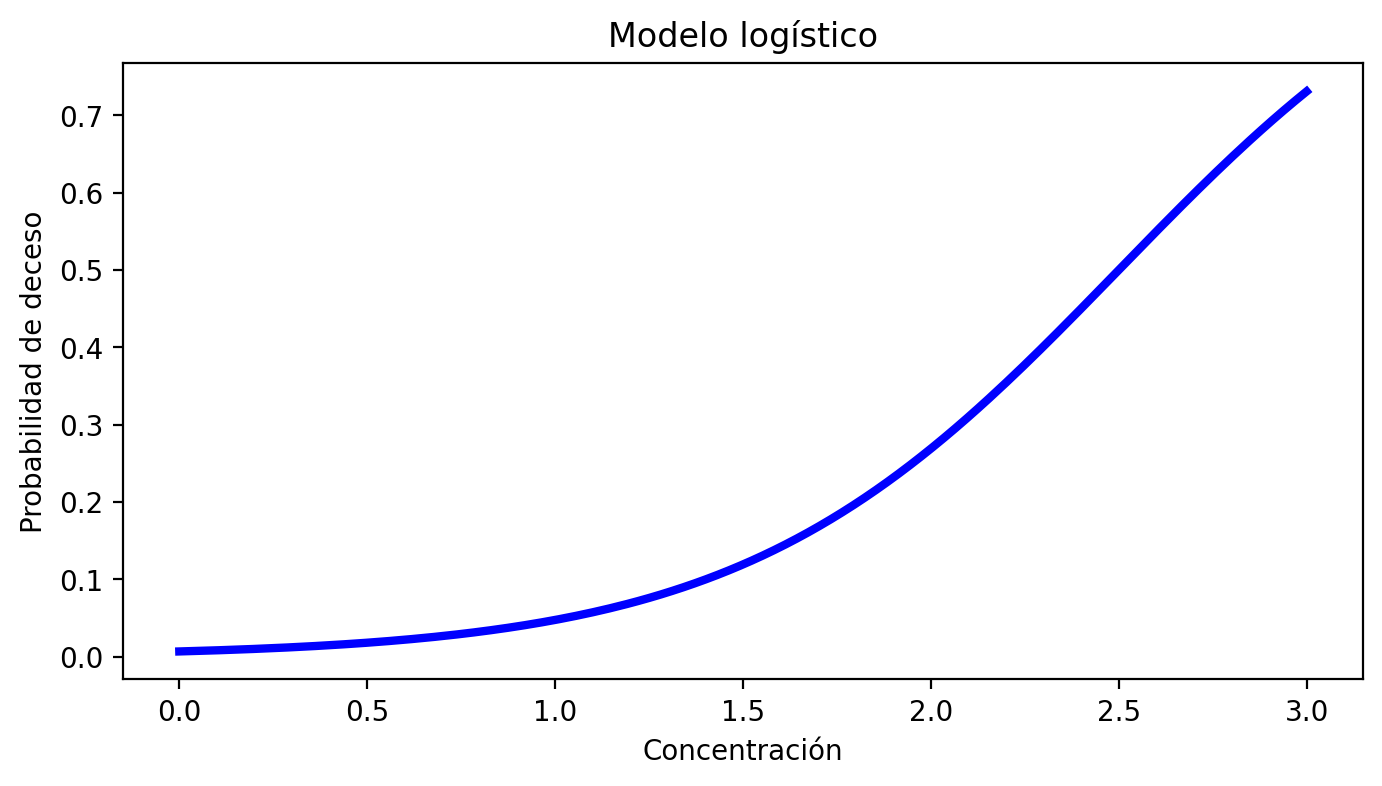

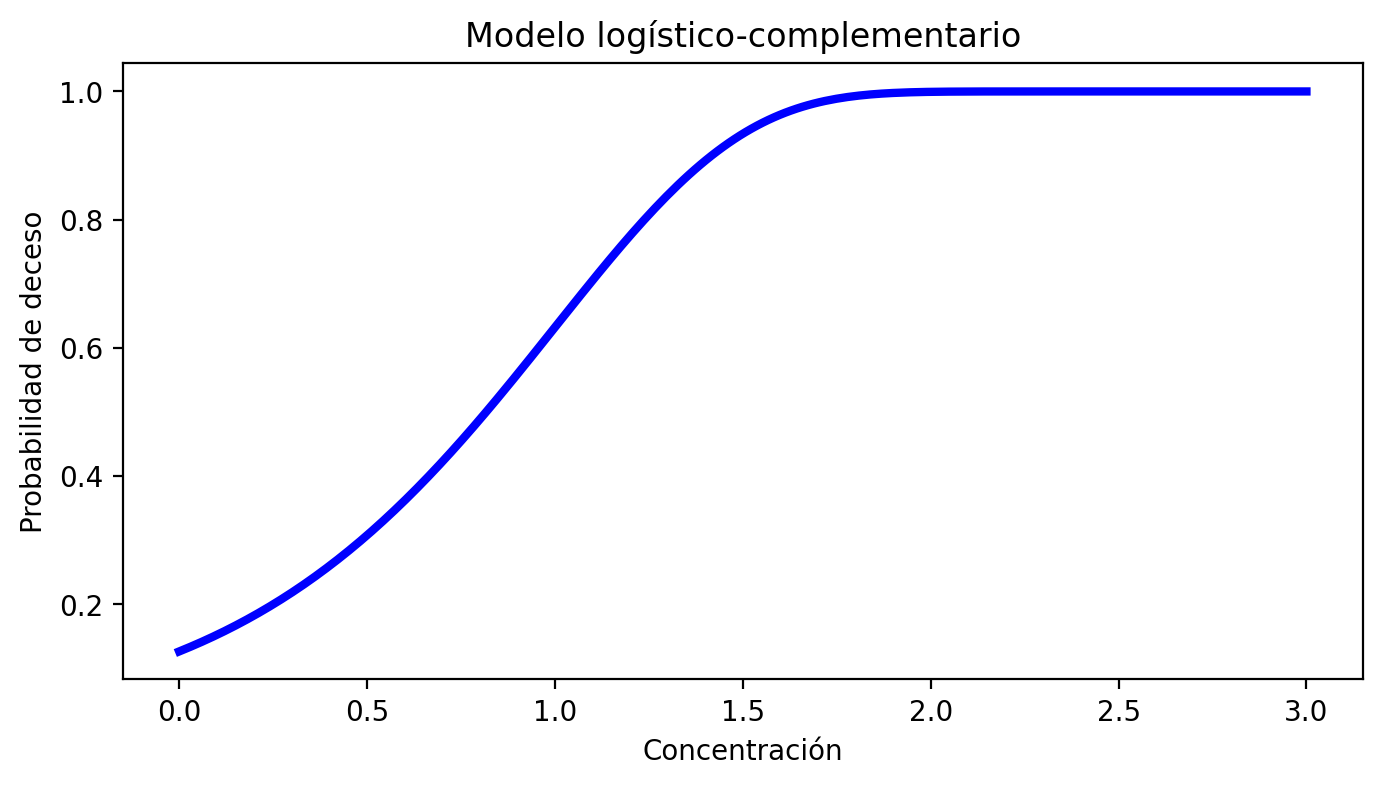

In [7]:
#Gráfico de los modelos de dependencia
x = np.linspace(0, 3, 200)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, logist(x), color ="blue", linewidth = 3)
ax.set_title("Modelo logístico")
ax.set_xlabel("Concentración")
ax.set_ylabel("Probabilidad de deceso")
plt.show()

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(x, log_com(x), color ="blue", linewidth = 3)
ax.set_title("Modelo logístico-complementario")
ax.set_xlabel("Concentración")
ax.set_ylabel("Probabilidad de deceso")
plt.show()

##Función de verosimilitud

Las funciones $\tilde \pi, \bar \pi $ son de la forma $ \mathbb{P}(Y=1 | x)$, queremos inferir la forma de las funciones dados los resultados de los experimentos, es decir, cual es la mejor manera de modelar la probabilidad de deceso dada una concentración. La forma de cada función esta determinada por los parámetros $\alpha$ y $\beta$, m'as aún, para cualquieras sean los valores reales de $\alpha$ y $\beta$ tenemos que $0 \leq \tilde \pi, \bar \pi \leq 1$  por lo que el espacio donde buscamos los parámetros es $\mathbb R ^2$. 

Si $Y$ es la variable aleatoria indicatriz de deceso de un escarabajo bajo la concentración $x$, vemos que $Y$ es una Bernoulli de parámetro $\pi(x)$. Como los datos vienen agrupados consideramos el $i$-ésimo experimento como la suma de la v.a. que representa cada escarabajo. Por lo que podemos definir: $Z_i$ la cantidad de decesos de $n_i$ escarabajos expuestos a la concentración $x_i$ que distribuye como una Binomial($n_i, \pi(x)$). Es importante notar que la muestra tomada por los experimentos $(Z_i)_{i=1}^8$ son independientes pero no distribuyen de la misma manera.

Con todo lo anterior vemos que, la función general de la verosimilitud $L$ y log-verosimilitud $l$ es de la forma
$$
   L(\alpha,\beta) = \prod_{i=1}^8 \mathbb{P}_{\alpha,\beta}(z_i = k) = \prod_{i=1}^8 \binom{n_i}{z_i}\pi(x)^{z_i}(1-\pi(x))^{n_i - z_i}
$$

$$
l(\alpha,\beta) = \sum_{i=1}^8 (\operatorname{log} (\binom{n_i}{z_i} + {z_i}\operatorname{log}\pi(x)    + (n_i - z_i)\operatorname{log}(1-\pi(x)))
$$


Para las funciones ver. y log-ver asociadas a $\tilde \pi$ y $\bar \pi $ notadas como $\tilde L, \tilde l$ y $\bar L, \bar l$ respectivamente, obtenemos para $\tilde \pi$

$$
\tilde L(\alpha_1, \beta_1) = \prod_{i=1}^k \binom{n_i}{z_i}( \frac{\exp(\alpha_1 + \beta_1 x_i)}{1 + \exp(\alpha_1 + \beta_1 x_i)} )^{z_i}( \frac{1}{1 + \exp(\alpha_1 + \beta_1 x_i)})^{n_i - z_i}
$$
$$
\tilde l(\alpha_1, \beta_1) = \sum_{i=1}^8 ( \operatorname{log}\binom{n_i}{z_i} + z_i (\alpha_1 + \beta_1 x_i) - n_i \operatorname{log}(1 + \exp(\alpha_1 + \beta_1 x_i)))
$$

y para \bar \pi

$$
\bar L(\alpha_2, \beta_2) = \prod_{i=1}^8 \binom{n_i}{z_i} (1 - \exp(-\exp(\alpha_2 + \beta_2 x_i)))^{z_i} (\exp(-\exp(\alpha_2 + \beta_2 x_i)))^{n_i - z_i}
$$

$$
\bar l(\alpha_2, \beta_2) = \sum_{i=1}^8 (\operatorname{log}\binom{n_i}{z_i} + z_i \ln(1 - \exp(-\exp(\alpha_2 + \beta_2 x_i))) - (n_i - z_i) \exp(\alpha_2 + \beta_2 x_i))
$$

In [29]:
##Código de las funciones log-ver para la primera distribución

# Cargar datos
df = pd.read_csv("../data/raw/datos_pesticida.csv")

concentracion = df["concentracion"].to_numpy()
Z = df[" nMuertos"].to_numpy()
N = df[" nExpuestos"].to_numpy()

def l_vtilde(alpha, beta):
    AUX = alpha + beta * concentracion

    Comb = comb(N, Z)
    coordenada = np.log(Comb) + Z*AUX - N*(np.log(1+np.exp(AUX)))

    return np.sum(coordenada)

def l_vbar(alpha, beta):
    AUX = alpha + beta * concentracion
    Comb = comb(N, Z)
    coordenada = np.log(Comb) + Z*np.log(1 - np.exp(- np.exp(AUX))) - (N - Z)*np.exp(AUX)

    return np.sum(coordenada)


<Figure size 1280x960 with 0 Axes>

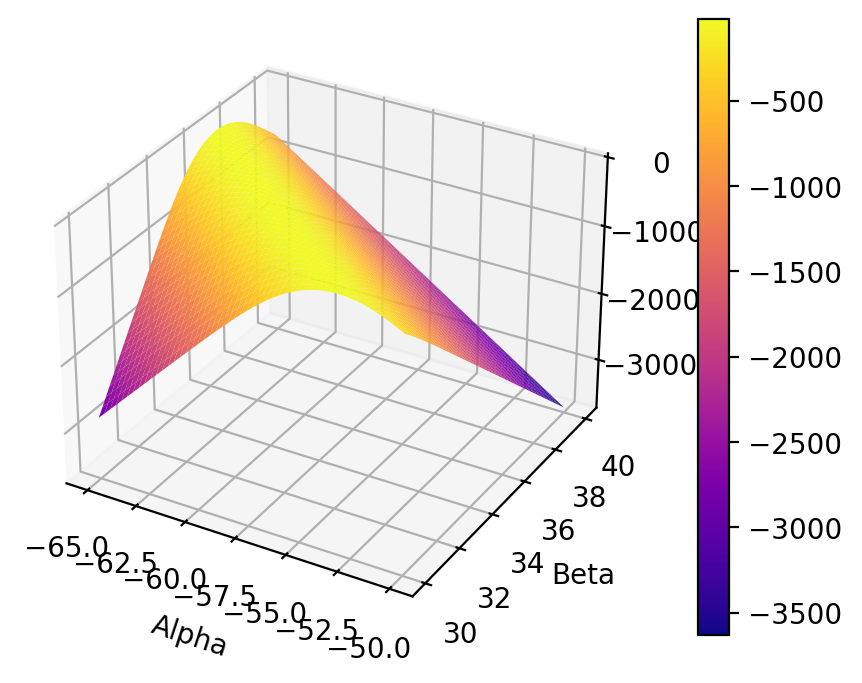

<Figure size 1280x960 with 0 Axes>

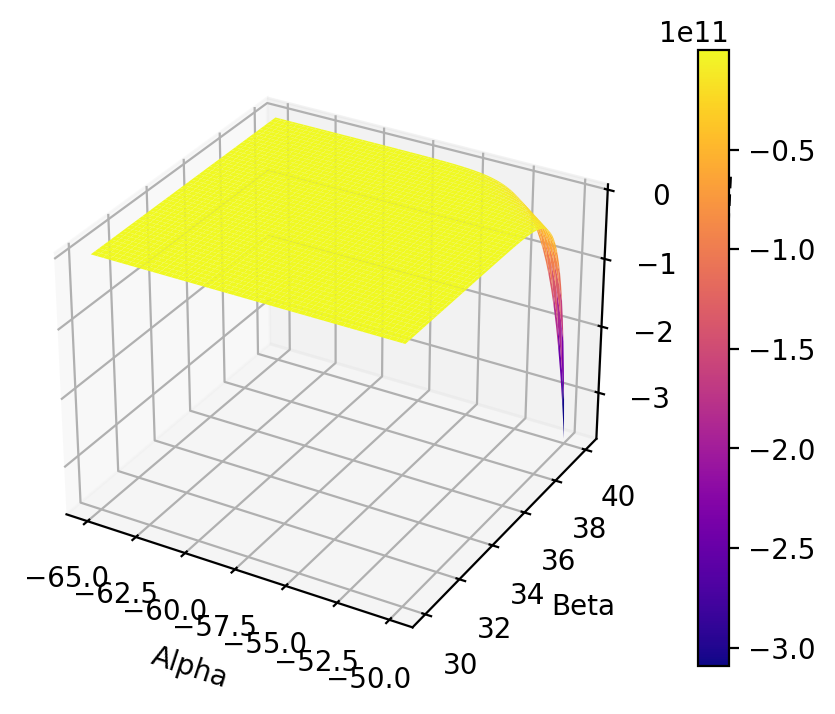

In [30]:
from numpy import meshgrid


x = np.linspace(-65, -50, 100)
y = np.linspace(30, 40, 100)
ALPHA, BETA = meshgrid(x, y)

l_v1 = np.vectorize(l_vtilde)
l_v2 = np.vectorize(l_vbar)
z1 = l_v1(ALPHA, BETA)
z2 = l_v2(ALPHA, BETA)

fig1 = plt.figure()
fig1 = plt.figure(figsize=(8, 4))
ax1 = fig1.add_subplot(projection="3d")
surf = ax1.plot_surface(ALPHA, BETA, z1, cmap="plasma")
ax1.set_xlabel("Alpha")
ax1.set_ylabel("Beta")
ax1.set_zlabel("Log-Verosimilitud")
fig1.colorbar(surf)

fig2 = plt.figure()
fig2 = plt.figure(figsize=(8, 4))
ax2 = fig2.add_subplot(projection="3d")
surf = ax2.plot_surface(ALPHA, BETA, z2, cmap="plasma")
ax2.set_xlabel("Alpha")
ax2.set_ylabel("Beta")
ax2.set_zlabel("Log-Verosimilitud")
fig2.colorbar(surf)

plt.show()

In [34]:
##Optimización funcion log-verosimilitud

def funcion_objetivo1(vars):
    x_0, y_0 = vars
    return -l_vtilde(x_0,y_0)

def funcion_objetivo2(vars):
    x_0, y_0 = vars
    return -l_vbar(x_0,y_0)

resultado1 = minimize(funcion_objetivo1, [0,0])
resultado2 = minimize(funcion_objetivo2, [0,0])

print(resultado1)
print(resultado1.x)

print()
print(resultado2)
print(resultado2.x)


  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 21.513206227493473
        x: [-5.984e+01  3.378e+01]
      nit: 14
      jac: [ 2.146e-06  3.815e-06]
 hess_inv: [[ 1.361e+01 -7.657e+00]
            [-7.657e+00  4.311e+00]]
     nfev: 51
     njev: 17
[-59.84029704  33.78021979]

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 21.540216843199232
        x: [-3.696e+01  2.057e+01]
      nit: 11
      jac: [ 9.537e-07  1.431e-06]
 hess_inv: [[ 8.344e+00 -4.627e+00]
            [-4.627e+00  2.567e+00]]
     nfev: 48
     njev: 16
[-36.9596288   20.57269206]


##La optimización fue un éxito y los valores óptimos de $\alpha$ y $\beta$ fueron:

Para $\tilde \pi(x)$:
$$
\alpha_1 = -59.84029704, \beta_1 =  33.78021979
$$
Para $\bar \pi (x)$:
$$
\alpha_2 = -36.9596288, \beta_2 = 20.57269206
$$

[-59.84029704  33.78021979]


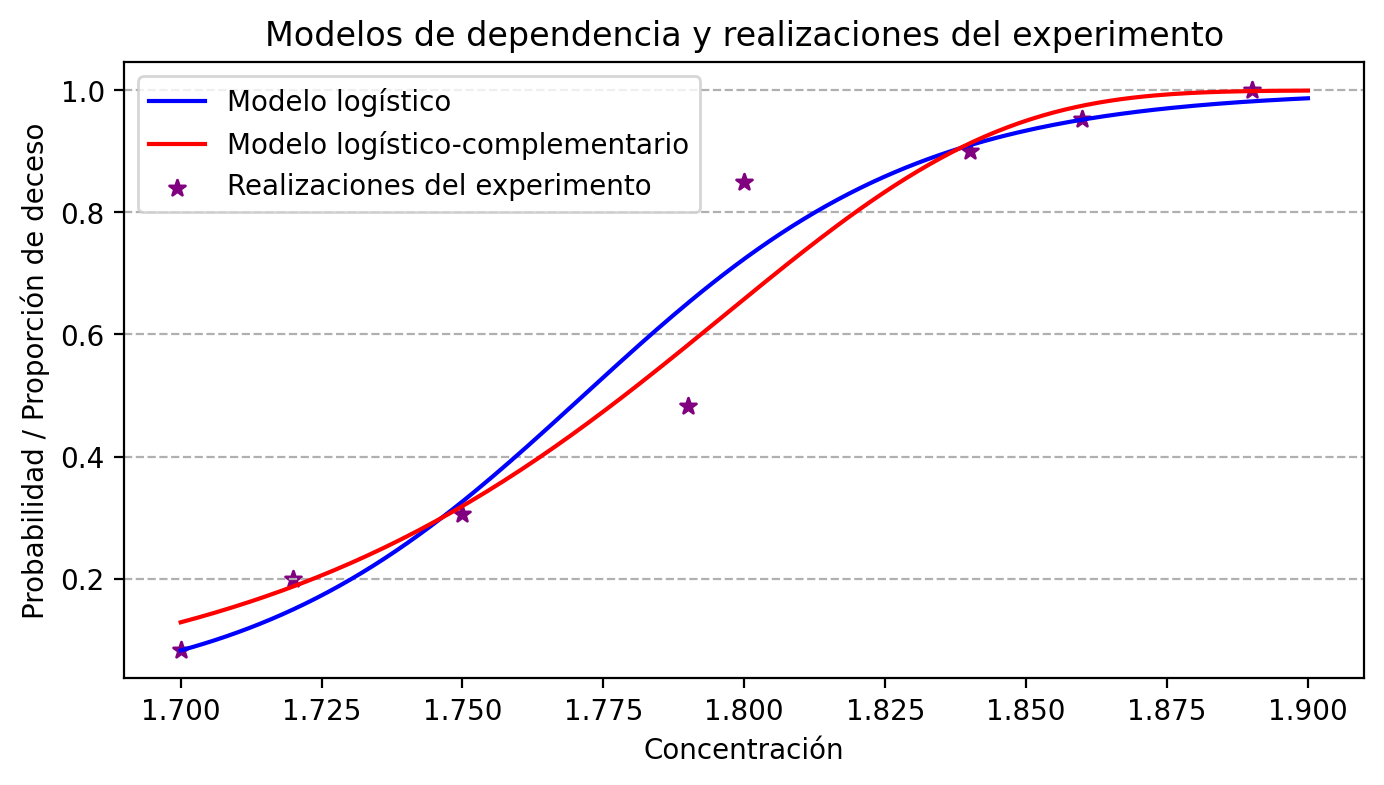

In [55]:
##Comparaciones de las densidades junto a los datos empíricos

x = np.linspace(1.7, 1.9, 200)
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x,logist(x, resultado1.x[0], resultado1.x[1]),color="blue",label="Modelo logístico",)
ax.plot(x,log_com(x, resultado2.x[0], resultado2.x[1]),color="red",label="Modelo logístico-complementario",)
ax.scatter(concentracion,Z/N,color="purple", marker = "*",label="Realizaciones del experimento")

ax.set_title("Modelos de dependencia y realizaciones del experimento")
ax.set_xlabel("Concentración")
ax.set_ylabel("Probabilidad / Proporción de deceso")
ax.grid(axis="y", linestyle="--")
ax.legend()

plt.show()

In [ ]:
## Comparación entre modelos y los resultados empíricos
print(concentracion)
print(Z)
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(concentracion, Z/N, color ="blue", linewidth = 3)
ax.set_title("Realizaciónes del experimento")
ax.set_xlabel("Concentración")
ax.set_ylabel("Probabilidad de deceso")
plt.show()